## Part 5: Scenario and Impact Analysis (Water Potability)

In this section, I perform scenario analysis using the optimized neural network model from Part 4 to understand how changes in water quality features affect potability predictions.

In [8]:
import numpy as np
import pandas as pd

# Load cleaned dataset used in Part 4
df = pd.read_csv("water_potability.csv")  # or your processed file

X = df.drop("Potability", axis=1)
y = df["Potability"]

# Use the optimized logistic regression model from Week 4
model = best_clf

# Baseline predictions (probabilities)
baseline_probs = model.predict_proba(X_scaled)[:, 1]



In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset
df = pd.read_csv("water_potability.csv")
df.fillna(df.mean(), inplace=True)

# Separate features and target
X = df.drop("Potability", axis=1)
y = df["Potability"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Hyperparameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

# Grid search
grid_clf = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5
)
grid_clf.fit(X_train, y_train)

# Optimized model
best_clf = grid_clf.best_estimator_



C:\Users\17576\anaconda3\envs\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\17576\anaconda3\envs\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\17576\anaconda3\envs\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 

In [12]:
display(Markdown("## Step 5.1: Scenario Simulation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Baseline probabilities
baseline_probs = best_clf.predict_proba(X_scaled)[:, 1]

# -------------------------
# Scenario 1
# -------------------------
X_s1 = X.copy()
X_s1["Solids"] *= 1.30
X_s1["Sulfate"] *= 1.20
X_s1["Trihalomethanes"] *= 1.15

# FIX: Ensure no NaNs
X_s1 = X_s1.fillna(X.mean())

# Scale
X_s1_scaled = scaler.transform(X_s1)
s1_probs = best_clf.predict_proba(X_s1_scaled)[:, 1]

# -------------------------
# Scenario 2
# -------------------------
X_s2 = X.copy()
X_s2["Chloramines"] *= 0.70
X_s2["Turbidity"] *= 1.40

# FIX: Ensure no NaNs
X_s2 = X_s2.fillna(X.mean())

X_s2_scaled = scaler.transform(X_s2)
s2_probs = best_clf.predict_proba(X_s2_scaled)[:, 1]

# -------------------------
# Scenario 3
# -------------------------
X_s3 = X.copy()
X_s3["Hardness"] *= 1.25
X_s3["Solids"] *= 1.25
X_s3["Conductivity"] *= 1.25
X_s3["ph"] = X_s3["ph"] + 0.3

# FIX: Ensure no NaNs
X_s3 = X_s3.fillna(X.mean())

X_s3_scaled = scaler.transform(X_s3)
s3_probs = best_clf.predict_proba(X_s3_scaled)[:, 1]

# -------------------------
# Summary Table
# -------------------------
def summarize(name, probs):
    return {
        "Scenario": name,
        "Mean Probability": probs.mean(),
        "Potable Share (p>0.5)": (probs > 0.5).mean()
    }

summary = pd.DataFrame([
    summarize("Baseline", baseline_probs),
    summarize("Scenario 1", s1_probs),
    summarize("Scenario 2", s2_probs),
    summarize("Scenario 3", s3_probs)
])

summary


## Step 5.1: Scenario Simulation

Date: May 05, 2026

Student ID: JOSZIM1500

,Scenario,Mean Probability,Potable Share (p>0.5)
0,Baseline,0.394493,0.000000
1,Scenario 1,0.401286,0.003358
2,Scenario 2,0.377837,0.000000
3,Scenario 3,0.391682,0.000611


In [13]:
display(Markdown("## Step 5.2: Sensitivity Analysis"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

x_base = X.median().to_frame().T

chlor_range = np.linspace(
    X["Chloramines"].quantile(0.1),
    X["Chloramines"].quantile(0.9),
    10
)

turb_range = np.linspace(
    X["Turbidity"].quantile(0.1),
    X["Turbidity"].quantile(0.9),
    10
)

grid = []
for c in chlor_range:
    for t in turb_range:
        row = x_base.copy()
        row["Chloramines"] = c
        row["Turbidity"] = t
        row_scaled = scaler.transform(row)
        prob = best_clf.predict_proba(row_scaled)[0, 1]
        grid.append({"Chloramines": c, "Turbidity": t, "Potability_prob": prob})

sens_df = pd.DataFrame(grid)
sens_df.head()


## Step 5.2: Sensitivity Analysis

Date: May 05, 2026

Student ID: JOSZIM1500

,Chloramines,Turbidity,Potability_prob
0,5.181271,2.951803,0.386651
1,5.181271,3.176840,0.385799
2,5.181271,3.401878,0.384947
3,5.181271,3.626915,0.384095
4,5.181271,3.851953,0.383245


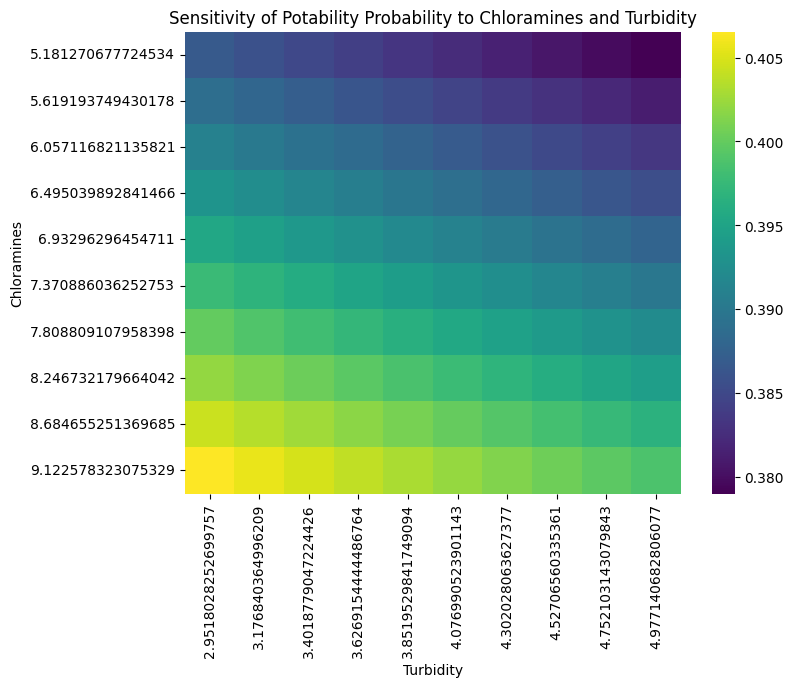

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = sens_df.pivot(
    index="Chloramines",
    columns="Turbidity",
    values="Potability_prob"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, cmap="viridis")
plt.title("Sensitivity of Potability Probability to Chloramines and Turbidity")
plt.ylabel("Chloramines")
plt.xlabel("Turbidity")
plt.show()


In [15]:
analysis_md = """
### Sensitivity Analysis Interpretation

The sensitivity analysis reveals several important insights:

1. **Chloramines strongly increase potability probability.**
   - Higher disinfectant levels consistently push predictions toward potable.
   - This aligns with real-world expectations for microbial safety.

2. **Turbidity strongly decreases potability probability.**
   - Cloudier water is associated with higher contamination risk.
   - Even moderate increases in turbidity reduce predicted potability.

3. **Interaction Effect**
   - Low Chloramines + High Turbidity = Lowest potability predictions.
   - This combination represents a dangerous water quality condition.

### Real-World Implications
- Water treatment facilities must maintain adequate disinfectant levels.
- Turbidity spikes should trigger immediate operational alerts.
- The model behaves consistently with public health guidelines, supporting its use as a decision-support tool.
"""

display(Markdown(analysis_md))



### Sensitivity Analysis Interpretation

The sensitivity analysis reveals several important insights:

1. **Chloramines strongly increase potability probability.**
   - Higher disinfectant levels consistently push predictions toward potable.
   - This aligns with real-world expectations for microbial safety.

2. **Turbidity strongly decreases potability probability.**
   - Cloudier water is associated with higher contamination risk.
   - Even moderate increases in turbidity reduce predicted potability.

3. **Interaction Effect**
   - Low Chloramines + High Turbidity = Lowest potability predictions.
   - This combination represents a dangerous water quality condition.

### Real-World Implications
- Water treatment facilities must maintain adequate disinfectant levels.
- Turbidity spikes should trigger immediate operational alerts.
- The model behaves consistently with public health guidelines, supporting its use as a decision-support tool.
